In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Installing dependencies...")
#!pip install -q transformers==4.46.0 accelerate torchaudio scikit-learn pandas numpy pillow

import torch
if torch.cuda.is_available():
    print(f"✅ Ready to go! GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ WARNING: You are running on CPU! Go to Runtime > Change runtime type > T4 GPU")

Mounted at /content/drive
Installing dependencies...
✅ Ready to go! GPU: Tesla T4


In [ ]:
import pickle
import os

# --- CONFIGURATION ---
TARGET_SUBJECT = 42
BASE_PATH = "/content/drive/MyDrive/Thesis_EAV"
EMOTIONS = {0: "Neutral", 1: "Calm", 2: "Happy", 3: "Sad", 4: "Angry"}

# Load Labels
print(f"📂 Scanning Subject {TARGET_SUBJECT} Test Data...")
label_path = f"{BASE_PATH}/Input_images/Audio/subject_{TARGET_SUBJECT:02d}_aud.pkl"

with open(label_path, 'rb') as f:
    # Index 3 is the Test Labels (y_test)
    test_labels = pickle.load(f)[3]

print(f"✅ Found {len(test_labels)} test clips.\n")
print("Here are the indices for ANGRY (Label 4) clips:")
print("------------------------------------------------")

found_count = 0
for i, label in enumerate(test_labels):
    if label == 4: # 4 = Angry
        print(f"👉 TRIAL_INDEX = {i}")
        found_count += 1
        # if found_count >= 5: # Just show the first 5 matches
        #     break

print("\n------------------------------------------------")
print("Use one of these numbers in your Simulation script!")

📂 Scanning Subject 42 Test Data...
✅ Found 120 test clips.

Here are the indices for ANGRY (Label 4) clips:
------------------------------------------------
👉 TRIAL_INDEX = 96
👉 TRIAL_INDEX = 97
👉 TRIAL_INDEX = 98
👉 TRIAL_INDEX = 99
👉 TRIAL_INDEX = 100
👉 TRIAL_INDEX = 101
👉 TRIAL_INDEX = 102
👉 TRIAL_INDEX = 103
👉 TRIAL_INDEX = 104
👉 TRIAL_INDEX = 105
👉 TRIAL_INDEX = 106
👉 TRIAL_INDEX = 107
👉 TRIAL_INDEX = 108
👉 TRIAL_INDEX = 109
👉 TRIAL_INDEX = 110
👉 TRIAL_INDEX = 111
👉 TRIAL_INDEX = 112
👉 TRIAL_INDEX = 113
👉 TRIAL_INDEX = 114
👉 TRIAL_INDEX = 115
👉 TRIAL_INDEX = 116
👉 TRIAL_INDEX = 117
👉 TRIAL_INDEX = 118
👉 TRIAL_INDEX = 119

------------------------------------------------
Use one of these numbers in your Simulation script!


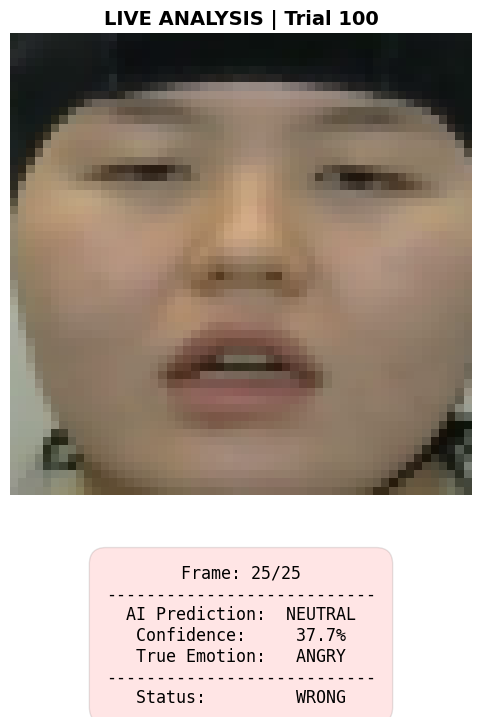

🏁 Simulation Complete.


In [ ]:
%matplotlib inline
import os
import time
import pickle
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from transformers import ASTForAudioClassification, AutoModelForImageClassification, ViTForImageClassification, AutoFeatureExtractor

# --- CONFIGURATION ---
TARGET_SUBJECT = 42
TRIAL_INDEX = 100  # <--- The specific video clip we are simulating
FPS = 2             # Speed of simulation (Frames per second)

# Paths
BASE_PATH = "/content/drive/MyDrive/Thesis_EAV"
PATH_AUD = f"{BASE_PATH}/trained_audio_UNIVERSAL.pth"
PATH_VIS = f"{BASE_PATH}/trained_vision_UNIVERSAL.pth"
PATH_EEG = f"{BASE_PATH}/trained_eeg_UNIVERSAL.pth"
EMOTIONS = {0: "Neutral", 1: "Calm", 2: "Happy", 3: "Sad", 4: "Angry"}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 1. LOAD MODELS ---
print("⚙️ Loading AI Models...")
aud_proc = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
m_aud = ASTForAudioClassification.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593", num_labels=5, ignore_mismatched_sizes=True).to(device).eval()
m_aud.load_state_dict(torch.load(PATH_AUD, map_location=device))

m_vis = AutoModelForImageClassification.from_pretrained("google/vit-base-patch16-224", num_labels=5, ignore_mismatched_sizes=True).to(device).eval()
m_vis.load_state_dict(torch.load(PATH_VIS, map_location=device))

if os.path.exists(PATH_EEG):
    m_eeg = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", num_labels=5, ignore_mismatched_sizes=True).to(device).eval()
    m_eeg.load_state_dict(torch.load(PATH_EEG, map_location=device))
else: m_eeg = None

# --- 2. LOAD DATA ---
print(f"📂 Extracting Clip #{TRIAL_INDEX} for Subject {TARGET_SUBJECT}...")

# Load full datasets
with open(f"{BASE_PATH}/Input_images/Audio/subject_{TARGET_SUBJECT:02d}_aud.pkl", 'rb') as f: all_aud = pickle.load(f)[2]
with open(f"{BASE_PATH}/Input_images/Vision/subject_{TARGET_SUBJECT:02d}_vis.pkl", 'rb') as f: all_vis = pickle.load(f)[2]
with open(f"{BASE_PATH}/Input_images/EEG/subject_{TARGET_SUBJECT:02d}_eeg.pkl", 'rb') as f: all_eeg = pickle.load(f)[2]
with open(f"{BASE_PATH}/Input_images/Audio/subject_{TARGET_SUBJECT:02d}_aud.pkl", 'rb') as f: all_labels = pickle.load(f)[3]

# Extract the SINGLE instance
raw_video = all_vis[TRIAL_INDEX]  # This should be (Frames, H, W, 3)
raw_audio = all_aud[TRIAL_INDEX]
raw_eeg = all_eeg[TRIAL_INDEX]
true_label = all_labels[TRIAL_INDEX]

# Handle single-image case (if dataset has no frames)
if raw_video.ndim == 3:
    print("⚠️ Notice: This sample is a single image, repeating it to simulate video.")
    raw_video = np.stack([raw_video] * 20) # Fake a 20-frame video

# --- 3. PRE-PROCESS CONSTANT INPUTS ---
# Audio/EEG are "context" for this clip
aud_in = aud_proc(raw_audio, sampling_rate=16000, padding="max_length", return_tensors="pt").input_values.to(device)

e_t = torch.tensor(raw_eeg, dtype=torch.float32)
if e_t.ndim == 1: e_t = e_t.unsqueeze(0)
eeg_in = F.interpolate(e_t.unsqueeze(0).unsqueeze(0), size=(224, 224), mode='bilinear', align_corners=False).repeat(1, 3, 1, 1).to(device)

# --- 4. LIVE LOOP ---
print("\n🚀 STARTING LIVE SIMULATION...")
time.sleep(1)

# Set figure size once
plt.rcParams["figure.figsize"] = (6, 6)

for i in range(len(raw_video)):
    # A. Get Frame
    frame = raw_video[i]

    # B. Predict (Vision updates every frame)
    v_t = torch.tensor(frame, dtype=torch.float32)
    if v_t.shape[-1] == 3: v_t = v_t.permute(2, 0, 1)
    vis_in = F.interpolate(v_t.unsqueeze(0), size=(224, 224), mode='bilinear', align_corners=False).to(device)

    with torch.no_grad():
        p_a = F.softmax(m_aud(aud_in).logits, dim=1)
        p_v = F.softmax(m_vis(vis_in).logits, dim=1)
        p_e = F.softmax(m_eeg(eeg_in).logits, dim=1) if m_eeg else 0

        final = (p_a + p_v + p_e) / 3.0 if m_eeg else (p_a + p_v) / 2.0

    pred_cls = torch.argmax(final).item()
    conf = final.max().item()

    # C. Visualize
    clear_output(wait=True)

    fig, ax = plt.subplots(1, 1)

    # Normalize image for display
    disp_img = frame / 255.0 if frame.max() > 1.0 else frame
    ax.imshow(disp_img)
    ax.axis('off')

    # Status
    color = 'green' if pred_cls == true_label else 'red'
    status_text = "CORRECT" if pred_cls == true_label else "WRONG"

    plt.title(f"LIVE ANALYSIS | Trial {TRIAL_INDEX}", fontsize=14, fontweight='bold')

    info_text = (
        f"Frame: {i+1}/{len(raw_video)}\n"
        f"---------------------------\n"
        f"AI Prediction:  {EMOTIONS[pred_cls].upper()}\n"
        f"Confidence:     {conf*100:.1f}%\n"
        f"True Emotion:   {EMOTIONS[true_label].upper()}\n"
        f"---------------------------\n"
        f"Status:         {status_text}"
    )

    plt.text(0.5, -0.15, info_text,
             horizontalalignment='center',
             verticalalignment='top',
             transform=ax.transAxes,
             fontsize=12, family='monospace',
             bbox=dict(facecolor=color, alpha=0.1, boxstyle='round,pad=1'))

    plt.show()
    plt.close(fig) # Cleanup

    # D. Control Speed
    time.sleep(1.0 / FPS)

print("🏁 Simulation Complete.")